0 2.5755958841625457
1 2.4468160899544174
2 2.278238049001562
3 2.0070101592942855
4 1.7233641596027525
5 1.3962165274064269
6 0.802124079088486
7 0.630283725014456
8 0.5546378344943843
9 0.5048138888486964
10 0.467882072640208
11 0.43791877809354496
12 0.4116484360419239
13 0.3888134904520726
14 0.3677319217988657
15 0.3484423595217123
16 0.3302728213217119
17 0.3134664938415721
18 0.2973143855750262
19 0.2823849141514705
20 0.2681749186682909
21 0.2546532838119795
22 0.2418884098504579
23 0.2297378187011052
24 0.21825092776605004
25 0.20733838137774807
26 0.19697146230886098
27 0.18712288919341802
28 0.17776674473374676
29 0.16887840749705862
30 0.16043448712220565
31 0.1524127627660956
32 0.14479212462779079
33 0.13755251839640126
34 0.13067489247658104
35 0.12414114785275254
36 0.1179340904601145
37 0.11203738593710888
38 0.10643551664025308
39 0.10111374080824076
40 0.09605805376782861
41 0.09125515107943727
42 0.08669239352546576
43 0.08235777384919185
44 0.0782398851567323
45 0.

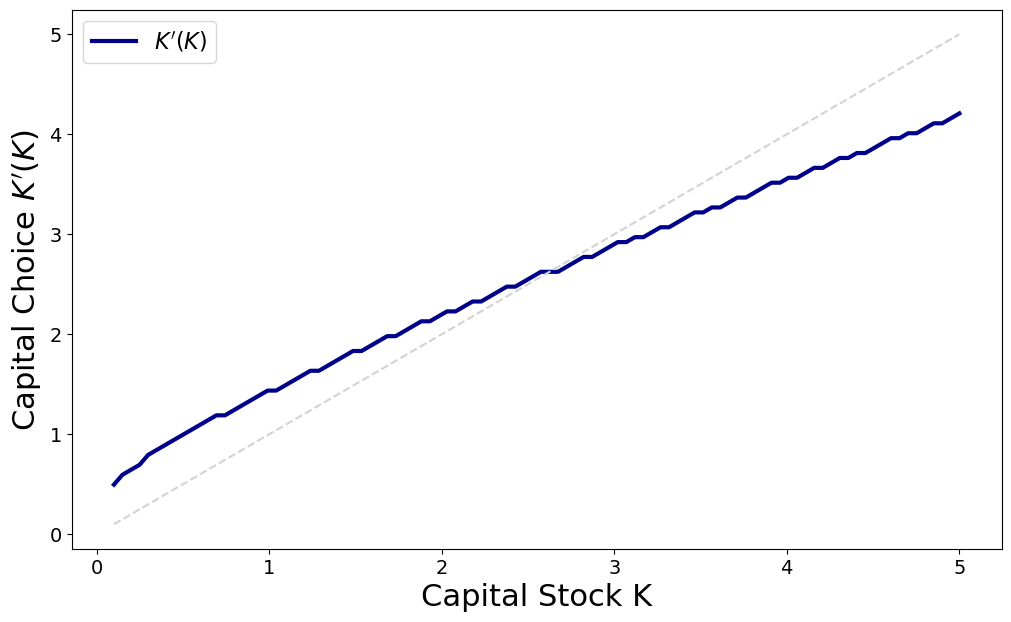

In [1]:
# Import the necessary libraries
import numpy as np
from scipy import interpolate, optimize
import matplotlib.pyplot as plt

# Optional
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

# Economic parameters
betta = 0.95
alpha = 0.3
delta = 0.1
sigma = 0.25

# Grid parameters
k_min = 0.1
k_max = 5.0
nk = 100

# Technical parameters
maxiter = 10000
tol = 1e-6

# Initialization
kgrid = np.linspace(k_min, k_max, nk)
V_guess = ((delta * kgrid) ** (1 - sigma) - 1) / ((1 - sigma) * (1 - betta))
k_guess = np.zeros(nk)

# Main Loop
for iter0 in range(maxiter):

    V_new = np.zeros(nk)

    for ik in range(nk):

        con = kgrid[ik] ** alpha + (1 - delta) * kgrid[ik] - kgrid
        idx_con_pos = np.where(con > 0)

        util = np.ones(nk) * (-1e6)
        util[idx_con_pos] = (con[idx_con_pos] ** (1 - sigma) - 1) / (1 - sigma)

        T_op = util + betta * V_guess

        V_new[ik] = np.amax(T_op)
        idx_max = np.argmax(T_op)
        k_guess[ik] = kgrid[idx_max]

    metric = np.amax(np.abs(V_guess - V_new))
    print(iter0, metric)
    if (metric < tol):
        break

    V_guess = V_new.copy()

fig,ax=plt.subplots(figsize=(12,7))
ax.plot(kgrid,k_guess,color="darkblue",linewidth=3,label="$K'(K)$")
ax.plot(kgrid, kgrid, color='lightgrey', linestyle='dashed')

ax.set_ylabel("Capital Choice $K'(K)$", fontsize=22)
ax.set_xlabel("Capital Stock K", fontsize=22)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.legend(fontsize= 16, loc='upper left')
plt.show()